# Simulating the Stockholm pod over a weather year

The blog post's plant is one Modelica model, exported as an FMU. This notebook
is that FMU made runnable in Python: it steps the committed `StockholmPod.fmu`
over a full Stockholm weather year, once per Open District Heating product, then
prints the annual table and the three data charts the post is built on.

Nothing here needs OpenModelica. The FMU carries its own solver; the only
input it can't compute for itself, the district network's weather-tracked
supply, return and demand curves, is precomputed once by `export_drive.mos`
into `network_inputs.csv`, which we read below.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from fmpy import extract, read_model_description
from fmpy.fmi2 import FMU2Slave

# Everything the notebook needs sits next to it.
HERE = Path.cwd()
FMU = HERE / "StockholmPod.fmu"
INPUTS = HERE / "network_inputs.csv"
IMAGES = HERE / "images"
IMAGES.mkdir(exist_ok=True)

## The input signals

`network_inputs.csv` holds one row per hour of the year: the ambient dry-bulb
temperature from the Stockholm Arlanda TMYx file, and the network supply,
return and demand curves that track it. These are exactly the signals
`StockholmPodStandalone` generates internally; we feed them to the bare pod
from outside.

The two temperature curves are digitised from Energiforsk 2024:1059, a
Swedish sector average over 213 systems rather than a Stockholm measurement.
The demand curve is not sourced at all — every constant in it is chosen, and
it decides how much of the pod's output is sellable, so every recovery figure
below is conditional on it. The chart further down shows how much sway that
has.

In [2]:
net = np.genfromtxt(INPUTS, delimiter=",", names=True)
HOURS = len(net)  # 8760
STEP = 3600.0
tAmb = net["tAmb"]
print(f"{HOURS} hourly rows; ambient {tAmb.min():.1f} .. {tAmb.max():.1f} degC")

8760 hourly rows; ambient -18.0 .. 30.0 degC


## Simulating the pod

`StockholmPod.fmu` is a co-simulation FMU, so it integrates itself between
steps; we hand it one hour of inputs at a time and read the outputs back.

The control inputs are pinned exactly as the standalone model pins them —
this is the committed operating point, not a dispatch:

- `qHpSet = fracLiq * pItNom = 8000 kW`: heat pump commanded to design duty.
- `yDry = 1`: dry cooler free to run at full fan duty.
- `yChg = 0`: accumulator uncommanded — it just decays on standing loss.
- `pIt = 10000 kW`: the flat 10 MW design load, all year.

Only `uProd` (1 Retur, 2 Inblandning, 3 Prima) changes between runs.

In [3]:
FRAC_LIQ, P_IT_NOM_KW = 0.8, 10000.0
CONTROLS = {
    "qHpSet": FRAC_LIQ * P_IT_NOM_KW,  # 8000 kW, design duty
    "yDry": 1.0,
    "yChg": 0.0,
    "pIt": P_IT_NOM_KW,
}
# Outputs to record each hour, plus the internal states the energy balance needs.
RECORD = ["qSold", "qDump", "pHp", "pDry", "pAir", "pGrid", "pItMeas",
          "tLiqSup", "tLiqRet", "tTankTop", "copHp", "tNetDel",
          "tank.T", "tankLoss.Q_flow", "pipRac.T", "pipCoo.T"]

_md = read_model_description(FMU)
_vr = {v.name: v.valueReference for v in _md.modelVariables}
_unzip = extract(str(FMU))


def run(uProd):
    """Step StockholmPod.fmu over the weather year for one product.

    Returns a dict of length-(HOURS+1) arrays on a time grid that starts at the
    initial point and lands on each hour boundary, so annual integrals line up
    with a Modelica run of the same model.

    The FMU is not torn down: this OpenModelica FMU aborts the process on
    fmi2Terminate, so we simply drop the finished instance and let the kernel
    reclaim it at exit. A fresh instance is created per product.
    """
    inputs = dict(CONTROLS, uProd=float(uProd))
    s = FMU2Slave(guid=_md.guid, unzipDirectory=_unzip,
                  modelIdentifier=_md.coSimulation.modelIdentifier,
                  instanceName=f"p{uProd}")
    s.instantiate(loggingOn=False)
    s.setupExperiment(startTime=0.0)
    s.enterInitializationMode()

    def push(h):
        drv = {"tAmb": net["tAmb"][h], "tNetSup": net["tNetSup"][h],
               "tNetRet": net["tNetRet"][h], "qDem": net["qDem"][h]}
        allin = dict(inputs, **drv)
        s.setReal([_vr[k] for k in allin], list(allin.values()))

    push(0)
    s.exitInitializationMode()

    rec = {name: [] for name in RECORD}
    t = [0.0]

    def sample():
        vals = s.getReal([_vr[n] for n in RECORD])
        for name, v in zip(RECORD, vals):
            rec[name].append(v)

    sample()
    for h in range(HOURS):
        push(h)
        s.doStep(h * STEP, STEP)
        t.append((h + 1) * STEP)
        sample()

    out = {name: np.array(v) for name, v in rec.items()}
    out["time"] = np.array(t)
    return out

In [4]:
PRODUCTS = {1: "Retur", 2: "Inblandning", 3: "Prima"}
runs = {code: run(code) for code in PRODUCTS}
print("ran:", ", ".join(f"{c} {n}" for c, n in PRODUCTS.items()))

ran: 1 Retur, 2 Inblandning, 3 Prima


## The annual table

These are the numbers the post quotes, computed here from the FMU outputs.
`Heat sold` is condenser heat handed to the network, so it counts the compressor
work the heat pump adds on top of the loop heat. `recovered` is that same heat
minus the work, i.e. the IT heat actually pulled off the loop, lower by exactly
the `HP work` column. The 65.9% of IT energy the network is billed for and the
55.7% it recovers are two different numbers, and the gap between them is the heat
pump's electricity.

`Demand-limited` is the share of hours where the network's appetite, not the
pod's output, sets what gets sold: the hours `qSold` has been pulled all the way
down to the hour's demand.

In [5]:
def integrate(y, t):
    """Trapezoidal integral of a kW signal over seconds, in MWh."""
    return float(np.trapezoid(y, t)) / 3.6e6

print(f"{'Product':<12}{'Heat sold':>12}{'of IT':>8}{'recovered':>11}"
      f"{'HP work':>12}{'Dem-limited':>14}")
for code, name in PRODUCTS.items():
    r = runs[code]; t = r["time"]
    it = integrate(r["pItMeas"], t)
    sold = integrate(r["qSold"], t)
    hp = integrate(r["pHp"], t)
    # Heat sold is condenser heat, so it counts the compressor work; the IT heat
    # actually pulled off the loop is sold minus that work.
    recovered = sold - hp
    # Demand is the binding limit when qSold has reached the hour's demand.
    dem = net["qDem"]
    bound = np.mean(r["qSold"][1:] >= dem - 1.0) * 100
    print(f"{name:<12}{sold:>9,.0f} MWh{100*sold/it:>7.1f}%{100*recovered/it:>10.1f}%"
          f"{hp:>9,.0f} MWh{bound:>12.1f} %")

Product        Heat sold   of IT  recovered     HP work   Dem-limited
Retur          56,517 MWh   64.5%      61.5%    2,651 MWh        31.1 %
Inblandning    57,768 MWh   65.9%      55.7%    8,986 MWh        34.9 %
Prima          57,768 MWh   65.9%      54.6%    9,918 MWh        34.9 %


### The balance closes

The model's closing identity, integrated over the year:

```
fracLiq*pIt + pHp  =  qSold + qDump + Δ(tank storage) + tank loss + Δ(loop storage)
```

The two storage terms are the difference between the tank's and the loop's
start and end states, so they are near zero once the loop has settled. The
residual below is what's left over, relative to the IT heat: the run's own
correctness check.

In [6]:
RHO, CP = 995.6, 4177.0
C_TANK = 500.0 * RHO * CP        # J/K, single well-mixed node
M_PLA = 200.0                    # kg, lumped loop fluid mass

def d_state(y):
    return (y[-1] - y[0])

for code, name in PRODUCTS.items():
    r = runs[code]; t = r["time"]
    source = integrate(FRAC_LIQ * r["pItMeas"] + r["pHp"], t)
    sold = integrate(r["qSold"], t)
    dump = integrate(r["qDump"], t)
    tank = C_TANK * d_state(r["tank.T"]) / 3.6e9          # MWh
    loss = integrate(r["tankLoss.Q_flow"] / 1000.0, t)    # W -> kW -> MWh
    loop = M_PLA * CP * (d_state(r["pipRac.T"]) + d_state(r["pipCoo.T"])) / 3.6e9
    sink = sold + dump + tank + loss + loop
    it = integrate(r["pItMeas"], t)
    print(f"{name:<12} residual / IT heat = {abs(source - sink)/it:.2e}")

Retur        residual / IT heat = 4.98e-12
Inblandning  residual / IT heat = 4.98e-12
Prima        residual / IT heat = 4.98e-12


## The three data charts

The same figures the post carries, redrawn from the FMU run.

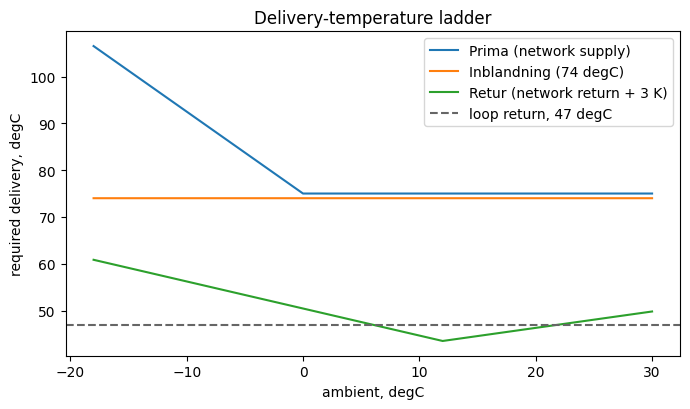

In [7]:
MONTH_DAYS = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
# Hour index at the start of each month.
MONTH_START = np.cumsum([0] + [d * 24 for d in MONTH_DAYS])

# --- Delivery-temperature ladder ---------------------------------------------
# Each product's required delivery temperature vs ambient, against the loop's
# constant 47 degC return. Retur tracks the network return + 3 K margin;
# Inblandning is flat 74 degC; Prima follows the network supply curve. All
# three requirements are Stockholm Exergi's, from the Oppen Fjarrvarme product
# sheet: Prima at what the network guarantees its customers (68-103 degC over
# the year), Inblandning at 68-80 degC year round (74 is the mid), Retur at
# least 3 degC above the incoming return.
order = np.argsort(tAmb)
xa = tAmb[order]
retur = net["tNetRet"][order] + 3.0
inbl = np.full_like(xa, 74.0)
prima = net["tNetSup"][order]
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(xa, prima, label="Prima (network supply)")
ax.plot(xa, inbl, label="Inblandning (74 degC)")
ax.plot(xa, retur, label="Retur (network return + 3 K)")
ax.axhline(47.0, ls="--", color="0.4", label="loop return, 47 degC")
ax.set_xlabel("ambient, degC"); ax.set_ylabel("required delivery, degC")
ax.set_title("Delivery-temperature ladder"); ax.legend(); fig.tight_layout()
fig.savefig(IMAGES / "post1-delivery-ladder.png", dpi=150)
plt.show()

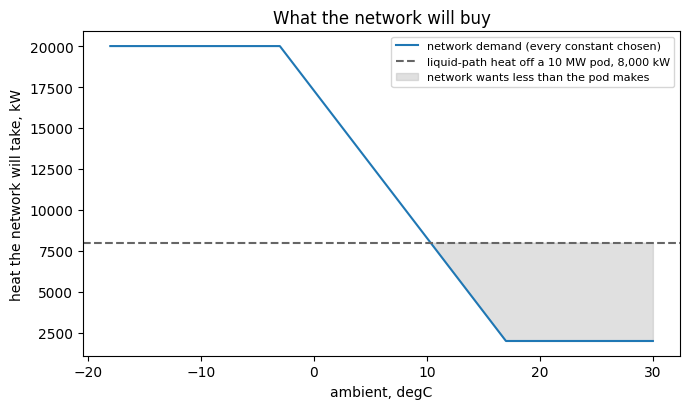

demand falls below the pod's liquid-path heat above 10.3 degC


In [8]:
# --- Network demand vs the heat the pod has to sell ---------------------------
# Every constant in this curve is chosen, not sourced: a 2 MW summer base,
# 900 kW per kelvin below a 17 degC balance point, capped at 20 MW. Where it
# crosses the pod's liquid-path heat is where the network stops being able to
# take everything, so the sold fractions in the table above hang off it.
POD_LIQUID_KW = FRAC_LIQ * P_IT_NOM_KW
dem = net["qDem"][order]
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(xa, dem, label="network demand (every constant chosen)")
ax.axhline(POD_LIQUID_KW, ls="--", color="0.4",
           label=f"liquid-path heat off a 10 MW pod, {POD_LIQUID_KW:,.0f} kW")
ax.fill_between(xa, dem, POD_LIQUID_KW, where=dem < POD_LIQUID_KW,
                color="0.7", alpha=0.4,
                label="network wants less than the pod makes")
ax.set_xlabel("ambient, degC")
ax.set_ylabel("heat the network will take, kW")
ax.set_title("What the network will buy"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(IMAGES / "post1-network-demand.png", dpi=150)
plt.show()

cross = xa[dem >= POD_LIQUID_KW].max()
print(f"demand falls below the pod's liquid-path heat above {cross:.1f} degC")

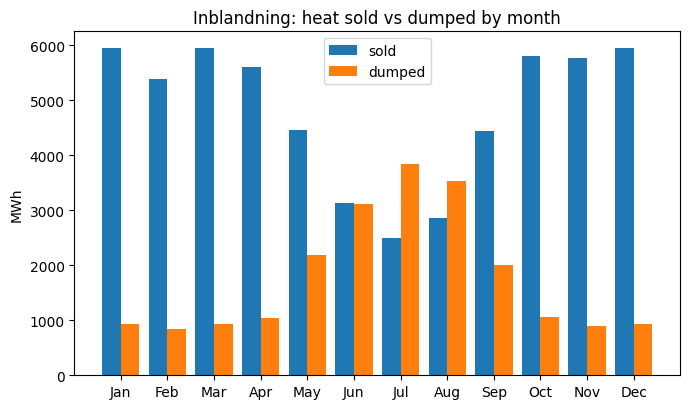

In [9]:
# --- Monthly heat sold vs dumped (Inblandning) -------------------------------
r = runs[2]
sold_h = r["qSold"][1:] * STEP / 3.6e6   # MWh per hour
dump_h = r["qDump"][1:] * STEP / 3.6e6
sold_m = [sold_h[MONTH_START[m]:MONTH_START[m+1]].sum() for m in range(12)]
dump_m = [dump_h[MONTH_START[m]:MONTH_START[m+1]].sum() for m in range(12)]
x = np.arange(12)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(x - 0.2, sold_m, 0.4, label="sold")
ax.bar(x + 0.2, dump_m, 0.4, label="dumped")
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("MWh"); ax.set_title("Inblandning: heat sold vs dumped by month")
ax.legend(); fig.tight_layout(); fig.savefig(IMAGES / "post1-monthly-sold-dumped.png", dpi=150)
plt.show()